# Tests of the sliding diffusion concept

The following with be experiements and tests of hyperparameter configurations, sometimes with numerical evalusaions, and prints for analasis. 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from local_attention import transformer
from local_attention.rotary import SinusoidalEmbeddings, apply_rotary_pos_emb
import matplotlib.pyplot as plt
from typing import Union
from io import BytesIO
from PIL import Image
from moviepy import ImageSequenceClip
from datetime import datetime
from v1_sliding_diffusion import Diffusion

device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu")

sqrt_alpha_hats torch.Size([100]) tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9999, 0.9931, 0.9797, 0.9598,
        0.9338, 0.9020, 0.8651, 0.8237, 0.7785, 0.7302, 0.6797, 0.6279, 0.5754,
        0.5231, 0.4718, 0.4219, 0.3742, 0.3290, 0.2868, 0.2478, 0.2122, 0.1801,
        0.1514, 0.1260, 0.1039, 0.0849, 0.0686, 0.0549, 0.0434, 0.0340, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000])
sqrt_one_minus_alpha_hats torch.Size([100]) tensor([0.0000, 0.0000, 0

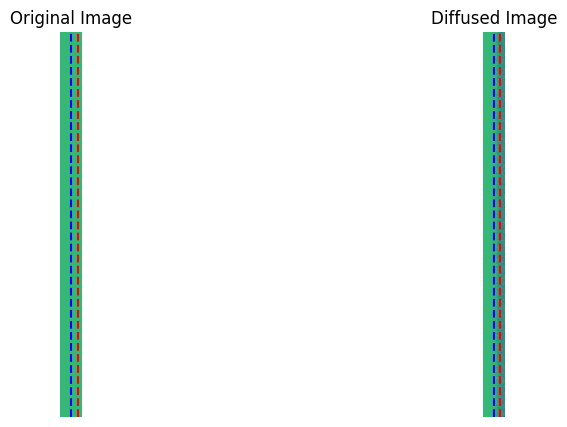

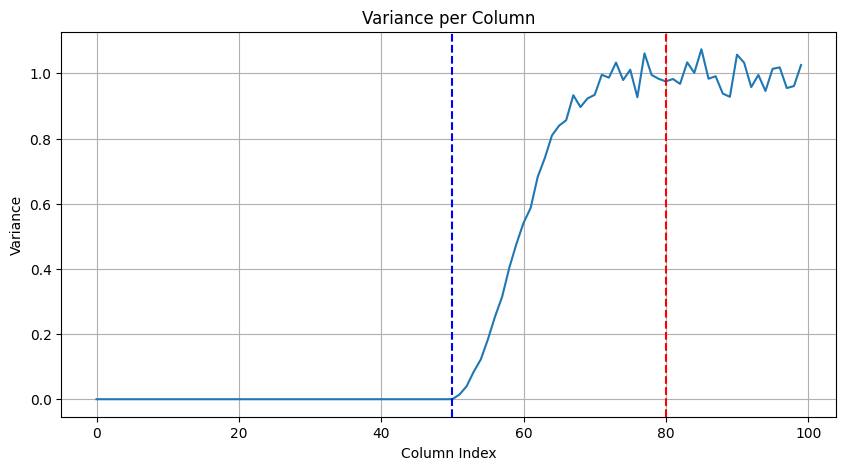

In [2]:
# Initialize the diffusion class
diffusion = Diffusion(
        num_of_pre_timestep_frames = 50, 
        num_of_timestep_frames = 30, 
        num_of_post_timestep_frames = 20, 
        noise_schedule = Diffusion.linear_schedule(0.0002, 0.40),
        device = device
    )

# Create a tensor that is all white so we can see the noising process removing details
image = torch.ones((177 * 10, 100))
image = image.to(device)

# Run the forward diffusion function
transformed_image = diffusion.forward(seqence_tensor = image)

# Draw both images next to each other in the python notebook
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image.cpu().numpy(), vmin=-3, vmax=3)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(transformed_image.cpu().numpy(), vmin=-3, vmax=3)
ax[1].set_title("Diffused Image")
ax[1].axis("off")

# Draw a vertical line at num_of_pre_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames
for a in ax:
    a.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
    a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

# Draw a vertical line at num_of_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames + diffusion.num_of_timestep_frames
for a in ax:
    a.axvline(x=line_x, color='red', linestyle='--', label='Timestep frames')
    a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

plt.show()

# Calculate the variance per frame (vertical slice)
variances = torch.var(transformed_image, dim=0)

# Plot the variance for each column
plt.figure(figsize=(10, 5))
plt.plot(variances.cpu().numpy())
plt.title("Variance per Column")
plt.xlabel("Column Index")
plt.ylabel("Variance")
plt.grid(True)

# Draw vertical lines at num_of_pre_timestep_frames and num_of_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames
plt.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
plt.axvline(x=line_x + diffusion.num_of_timestep_frames, color='red', linestyle='--', label='Timestep frames')


plt.show()

In [3]:
from v1_model import ContinuousMotionModel
from debugger import Debugger
from v1_traing_loop import train
from v1_sliding_diffusion import Diffusion

### Experiment 01

In [4]:
model = ContinuousMotionModel(
        deffsion_noise_scheduler=Diffusion(
                device=device,
                num_of_pre_timestep_frames=50,
                num_of_timestep_frames=100,
                num_of_post_timestep_frames=0,
                noise_schedule=Diffusion.linear_schedule(0.0002, 0.005)),
        number_of_styles = 17,
        n_gesture_length = 150,
        audio_features_per_frame = 804,
        pose_features_per_frame = 345,
        number_of_attention_heads = 8,
        debugger = Debugger(
            on=True, 
            keys_for_printing_while_running=["ALL"]
        ),
        device=device,
)

sqrt_alpha_hats torch.Size([150]) tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9999, 0.9998, 0.9996, 0.9995,
        0.9993, 0.9990, 0.9988, 0.9985, 0.9982, 0.9979, 0.9976, 0.9972, 0.9968,
        0.9964, 0.9960, 0.9955, 0.9950, 0.9945, 0.9940, 0.9935, 0.9929, 0.9923,
        0.9917, 0.9910, 0.9903, 0.9896, 0.9889, 0.9882, 0.9874, 0.9866, 0.9858,
        0.9850, 0.9841, 0.9833, 0.9824, 0.9814, 0.9805, 0.9795, 0.9785, 0.9775,
        0.9765, 0.9754, 0.9743, 0.9732, 0.9721, 0.9710, 0.9698, 0.9686, 0.9674,
        0.9662, 0.9649, 0.9636, 0.9623, 0.9610, 0.9597, 0.9583, 0.9569, 0.9555,
      

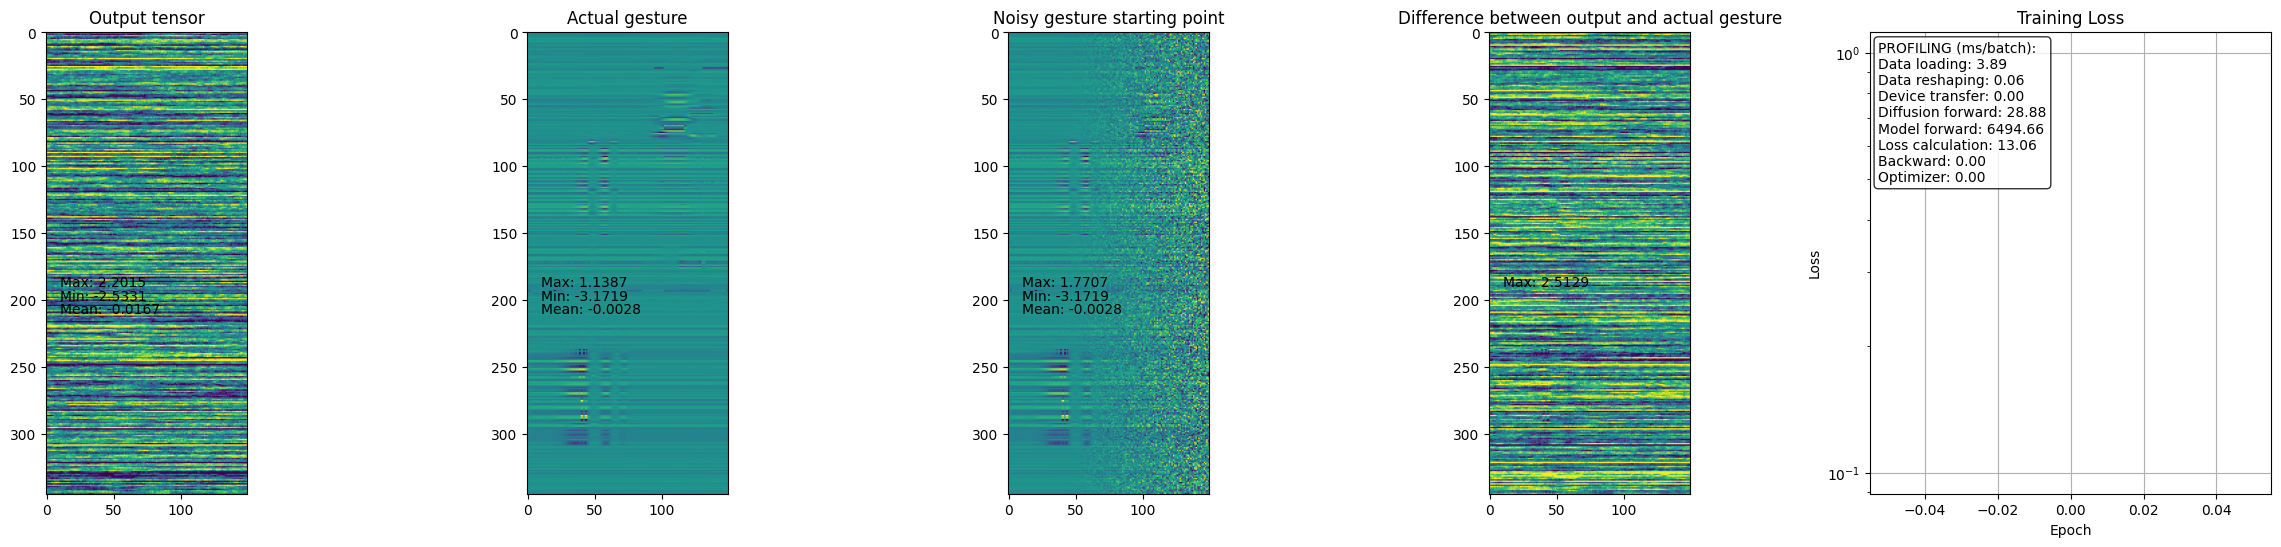

Epoch 1/1:   0%|          | 0/1 [00:07<?, ?it/s, loss=0.184]

Visualisation time: 1.00 s


RuntimeError: Found dtype BFloat16 but expected Float

In [5]:
from torch.utils.data import DataLoader
from dataset.dataset import *

train(
    model=model,
    diffusion=model.deffsion_noise_scheduler,
    device=device,
    training_loader=DataLoader(
            ConsolidatedRAMDataset(
                consolidated_file= "dataset/genea2023_dataset/trn/main-agent/consolidated.npz", # or "dataset/genea2023_dataset/trn/main-agent/training_windows_100k.npz"
                seq_length=150,
                seed_length=8,
                batch_size=10,
                epoch_length=1
            ),
            batch_size = 1,
            num_workers = 0,
            pin_memory = True
        ),
    val_loader=None, 
    num_epochs=1)

one_hot_style  max value:  tensor(1., dtype=torch.bfloat16)
one_hot_style  min value:  tensor(0., dtype=torch.bfloat16)
audio_features  max value:  tensor(52., dtype=torch.bfloat16)
audio_features  min value:  tensor(-16.6250, dtype=torch.bfloat16)
noisy_gesture_sequence  max value:  tensor(1.7734, dtype=torch.bfloat16)
noisy_gesture_sequence  min value:  tensor(-3.1719, dtype=torch.bfloat16)
timestep_0_pos_embedding  max value:  tensor(0.0032, grad_fn=<MaxBackward1>)
timestep_0_pos_embedding  min value:  tensor(-0.0050, grad_fn=<MinBackward1>)


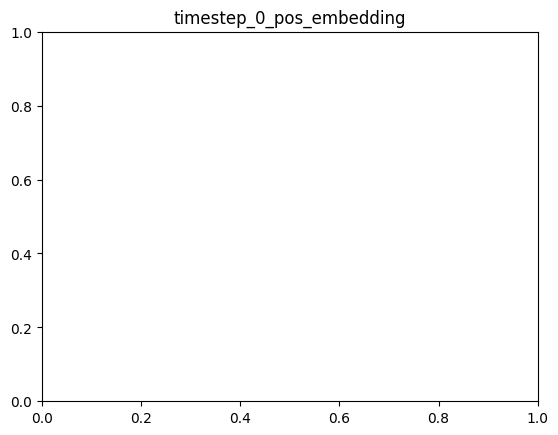

timestep_max_pos_embedding  max value:  tensor(0.4441, grad_fn=<MaxBackward1>)
timestep_max_pos_embedding  min value:  tensor(-0.4323, grad_fn=<MinBackward1>)


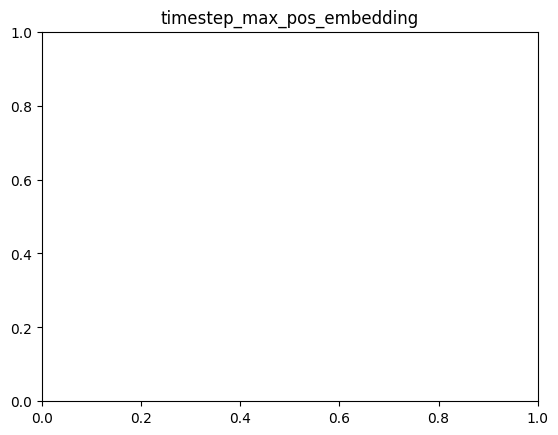

t_for_each_timestep_frame  max value:  tensor(0.9900)
t_for_each_timestep_frame  min value:  tensor(0.)


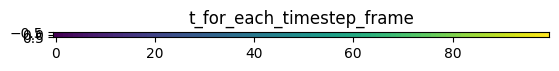

t_with_pos_embedding_for_each_timestep_frame - should be (t_for_each_timestep_frame, 192)  max value:  tensor(0.5499, grad_fn=<MaxBackward1>)
t_with_pos_embedding_for_each_timestep_frame - should be (t_for_each_timestep_frame, 192)  min value:  tensor(-0.6824, grad_fn=<MinBackward1>)


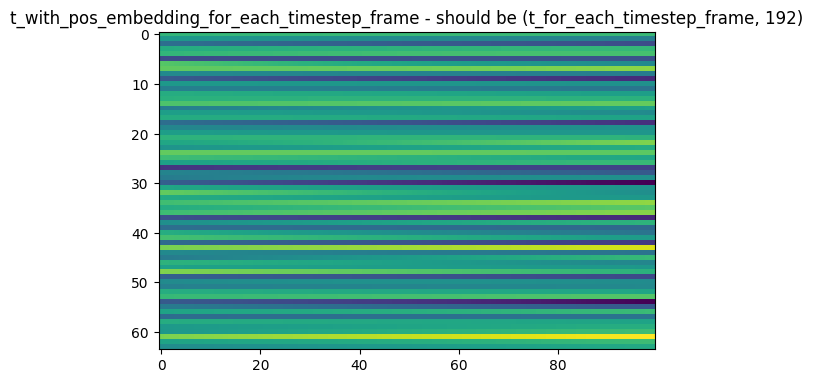

style after style_linear  max value:  tensor(0.3856, grad_fn=<MaxBackward1>)
style after style_linear  min value:  tensor(-0.4157, grad_fn=<MinBackward1>)


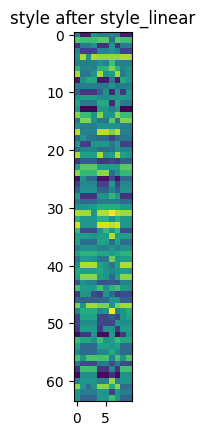

style after style_mask  max value:  tensor(0.3856, grad_fn=<MaxBackward1>)
style after style_mask  min value:  tensor(-0.4157, grad_fn=<MinBackward1>)


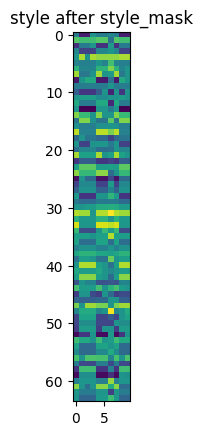

style_plus_t_0_pos_embedding  max value:  tensor(0.3861, grad_fn=<MaxBackward1>)
style_plus_t_0_pos_embedding  min value:  tensor(-0.4147, grad_fn=<MinBackward1>)


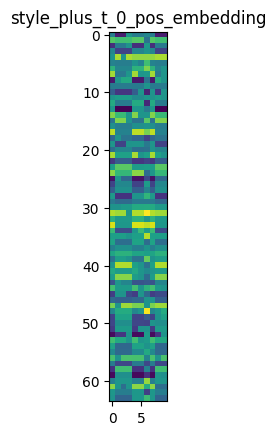

style_plus_t_max_pos_embedding  max value:  tensor(0.5122, grad_fn=<MaxBackward1>)
style_plus_t_max_pos_embedding  min value:  tensor(-0.6498, grad_fn=<MinBackward1>)


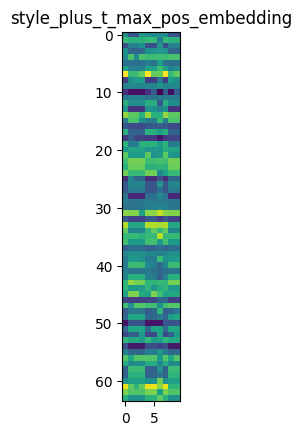

style_plus_t_for_each_timestep_frame  max value:  tensor(1.3756, grad_fn=<MaxBackward1>)
style_plus_t_for_each_timestep_frame  min value:  tensor(-0.4157, grad_fn=<MinBackward1>)


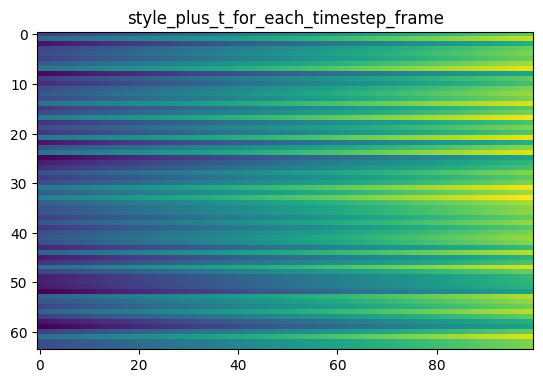

style_t_frames  max value:  tensor(1.3756, grad_fn=<MaxBackward1>)
style_t_frames  min value:  tensor(-0.4157, grad_fn=<MinBackward1>)


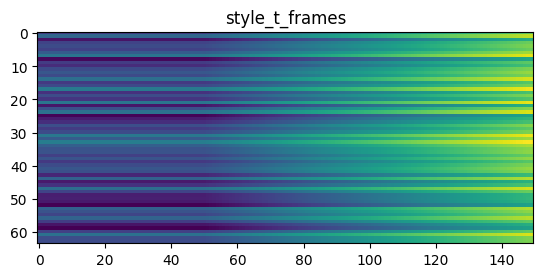

audio_features BEFORE audio_linear  max value:  tensor(52.)
audio_features BEFORE audio_linear  min value:  tensor(-16.6250)


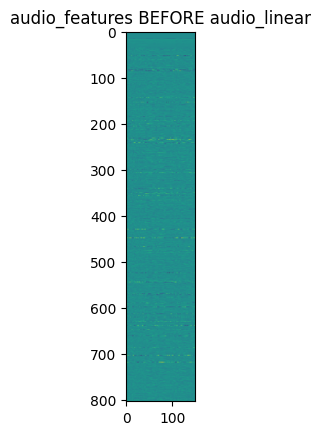

audio_features AFTER audio_linear  max value:  tensor(2.7640, grad_fn=<MaxBackward1>)
audio_features AFTER audio_linear  min value:  tensor(-3.7206, grad_fn=<MinBackward1>)


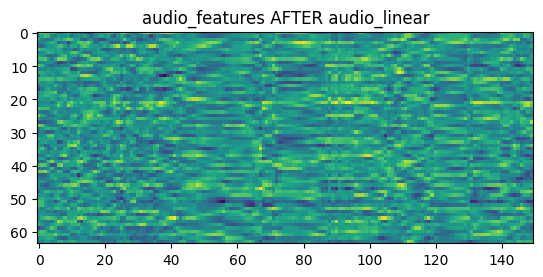

noisy_gesture_sequence AFTER noisy_gesture_linear  max value:  tensor(1.0879, grad_fn=<MaxBackward1>)
noisy_gesture_sequence AFTER noisy_gesture_linear  min value:  tensor(-1.1417, grad_fn=<MinBackward1>)


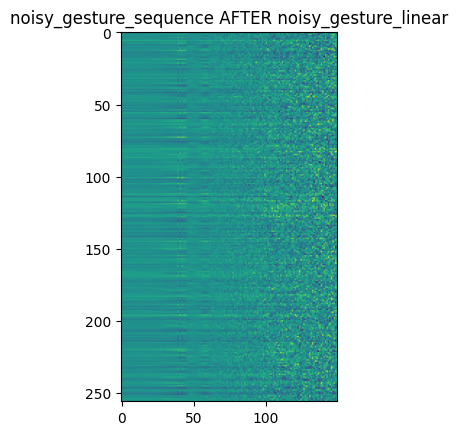

audio_noisy_gesture  max value:  tensor(2.7640, grad_fn=<MaxBackward1>)
audio_noisy_gesture  min value:  tensor(-3.7206, grad_fn=<MinBackward1>)


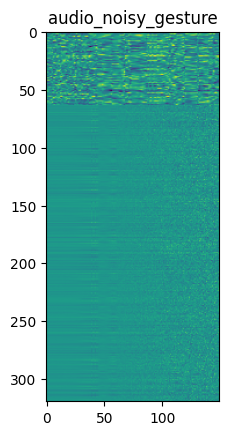

The final combied tensor of all the data  max value:  tensor(2.7640, grad_fn=<MaxBackward1>)
The final combied tensor of all the data  min value:  tensor(-3.7206, grad_fn=<MinBackward1>)


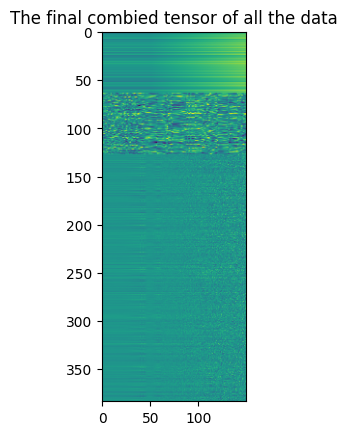

input after pre_local_attention_linear  max value:  tensor(1.2940, grad_fn=<MaxBackward1>)
input after pre_local_attention_linear  min value:  tensor(-1.1611, grad_fn=<MinBackward1>)


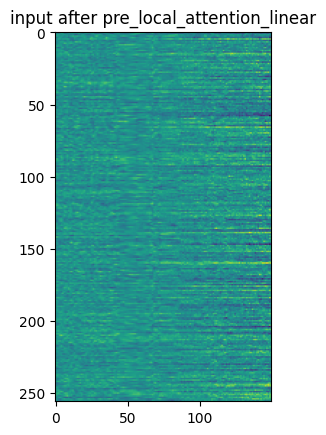

local_attention_output  max value:  tensor(0.2727, grad_fn=<MaxBackward1>)
local_attention_output  min value:  tensor(-0.3822, grad_fn=<MinBackward1>)


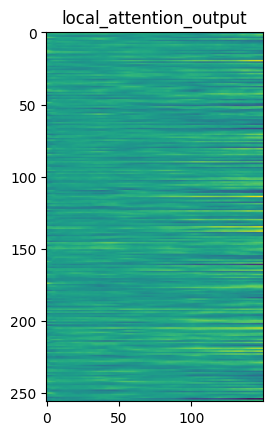

combined_tensor with RPE  max value:  tensor(0.2753, grad_fn=<MaxBackward1>)
combined_tensor with RPE  min value:  tensor(-0.3829, grad_fn=<MinBackward1>)


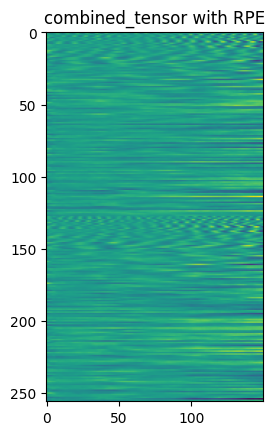

transformer_encoder_output  max value:  tensor(3.9836, grad_fn=<MaxBackward1>)
transformer_encoder_output  min value:  tensor(-4.4570, grad_fn=<MinBackward1>)


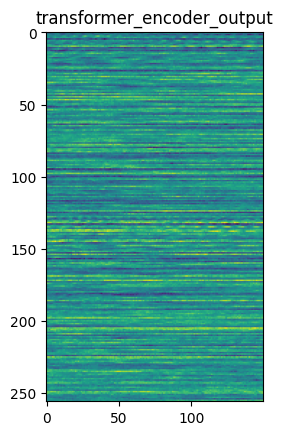

output_tensor  max value:  tensor(2.2015, grad_fn=<MaxBackward1>)
output_tensor  min value:  tensor(-2.5331, grad_fn=<MinBackward1>)


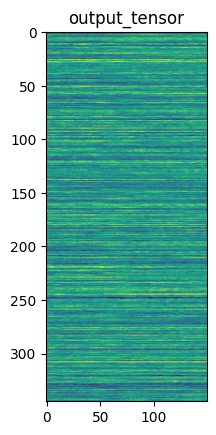

In [6]:
model.debugger.get_available_keys()
model.debugger.print_from_key("ALL")
